2025-09-14 16:55:08,489 - INFO - Sampled initial lengthscale (Optim mode: MAP): [2.14021381]
2025-09-14 16:55:08,491 - INFO - Using provided initial outputscale (Optim mode: FIX): 1.0
2025-09-14 16:55:08,512 - INFO - Sampled initial dof_func (Optim mode: MAP): 3.0919730205977984
2025-09-14 16:55:08,513 - INFO - Sampled initial dof_lik (Optim mode: MAP): 8.637599813284787
2025-09-14 16:55:08,514 - INFO - Sampled initial noisescale (Optim mode: MAP): 0.20118722687843976
2025-09-14 16:55:09,339 - INFO - Starting training for 200 epochs...
2025-09-14 16:55:10,347 - INFO - Epoch   10/200 | Fit Time: 0.037s | Loss: 915.261 | ELBO: -911.491
2025-09-14 16:55:10,353 - INFO - Epoch   10 | Test RMSE: 1.1399
2025-09-14 16:55:10,864 - INFO - Epoch   20/200 | Fit Time: 0.037s | Loss: 751.963 | ELBO: -748.190
2025-09-14 16:55:10,869 - INFO - Epoch   20 | Test RMSE: 1.0986
2025-09-14 16:55:11,380 - INFO - Epoch   30/200 | Fit Time: 0.037s | Loss: 612.299 | ELBO: -608.467
2025-09-14 16:55:11,386 - INFO

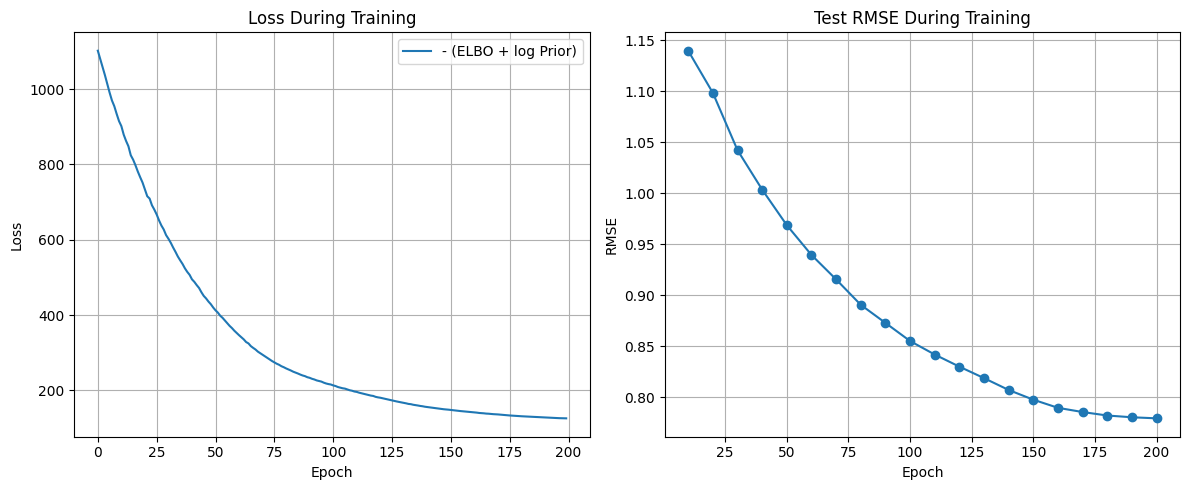

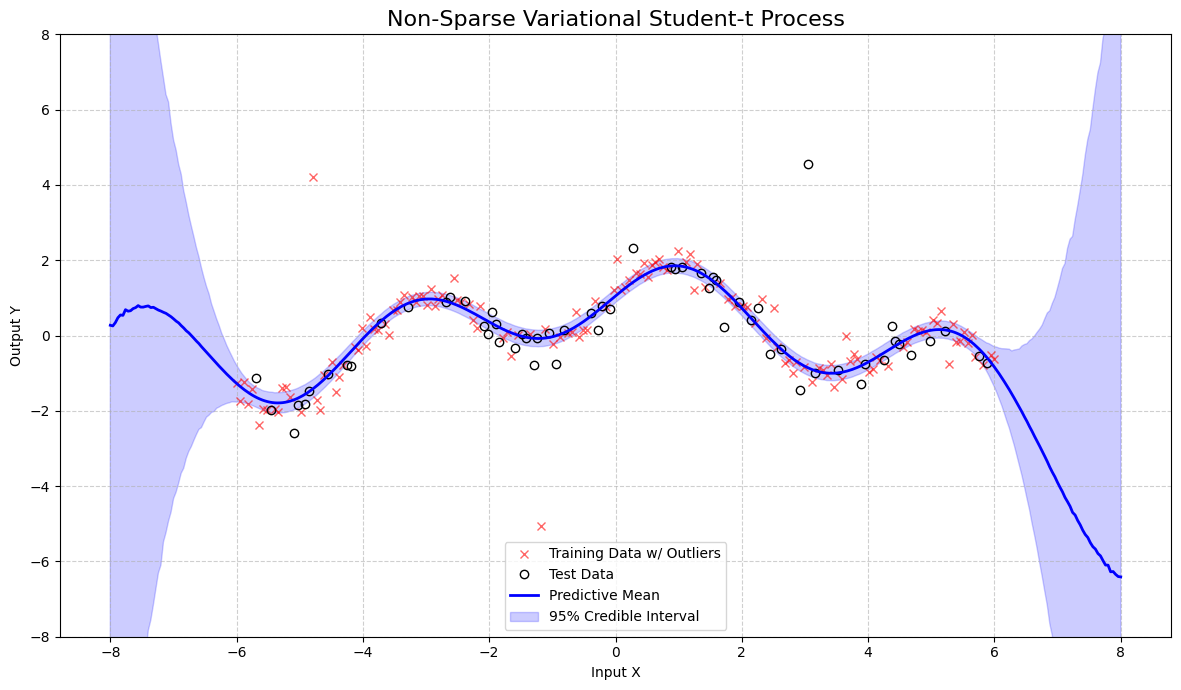

In [ ]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class XuTPR(nn.Module):
    """
    Non-Sparse Variational Student-t Process Regression.
    Refactored to support flexible hyperparameter optimization and evaluation.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape
        dtype = self.X_train.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0) # Prior for dof_func
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)   # Prior for dof_lik
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0) # Centered around exp(-2) ~ 0.13

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Variational Parameters for q(f) ---
        self.m = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.chol_S = nn.Parameter(torch.eye(self.N, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Set kernel function
        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_train.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = final_value

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        """Returns transformed (positive) parameters from their log-space storage."""
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior
    
    def calculate_elbo(self, num_samples=1):
        params = self._get_hyperparams()

        scale_tril_q = torch.tril(self.chol_S)
        f_samples = sample_mvt(self.m, scale_tril_q, params['dof_q'], num_samples)
        lik_dist = torch.distributions.StudentT(
            df=params['dof_lik'], loc=f_samples, scale=params['noisescale'] 
        )
        expected_log_lik = lik_dist.log_prob(self.y_train).sum(0).mean()

        K_XX_base = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
        K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
        K_XX_chol = K_XX_op.cholesky()
        
        kl_div = kl_mvt_empirical(
            mu_q=self.m,
            scale_tril_q=scale_tril_q,
            dof_q=params['dof_q'],
            mu_p=torch.zeros_like(self.m),
            scale_tril_p=K_XX_chol,
            dof_p=params['dof_func'],
            num_samples=num_samples
        )
        
        return expected_log_lik - kl_div

    def fit(self, epochs=200, lr=0.01, num_mc_samples=8, X_test=None, y_test=None, eval_interval=10):
        """Trains the model by maximizing the ELBO (plus log prior for MAP)."""
        
        # Select parameters to optimize based on the specified mode
        params_to_optimize = []
        for name, p in self.named_parameters():
            # Variational parameters are always optimized
            if name in ['m', 'chol_S', 'log_dof_q']:
                params_to_optimize.append(p)
            # Hyperparameters are optimized if not 'FIX'
            elif self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                params_to_optimize.append(p)

        optimizer = optim.Adam(params_to_optimize, lr=lr) if params_to_optimize else None
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'hyperparams': [],
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting training for {epochs} epochs...")

        for epoch in range(epochs):

            fit_start_time = time.time()

            optimizer.zero_grad()
            
            elbo = self.calculate_elbo(num_samples=num_mc_samples)
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(elbo + log_prior)
            
            loss.backward()
            optimizer.step()

            fit_end_time = time.time()

            # Store history
            history['elbo'].append(elbo.item())
            history['log_prior'].append(log_prior.item())
            history['loss'].append(loss.item())
            history['hyperparams'].append({k: v.detach().cpu().numpy() for k, v in self._get_hyperparams().items()})
            history['fit_times'].append(fit_end_time - fit_start_time)


            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")

            # Evaluation Step
            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        """Generates samples from the predictive distribution q(f*)."""
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_train.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            f_samples_posterior = sample_mvt(self.m, self.chol_S, params['dof_q'], num_samples)
            
            K_XX_base = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_train, params['lengthscale'], params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            K_inv_f_samples = K_XX_op.solve(f_samples_posterior)
            predictive_loc_per_sample = K_star_X @ K_inv_f_samples
            beta_per_sample = (f_samples_posterior * K_inv_f_samples).sum(0)
            dof_pred = params['dof_func'] + self.N
            
            K_star_X_K_inv = K_XX_op.solve(K_star_X.T).T
            term2 = (K_star_X_K_inv * K_star_X).sum(1)
            
            scale_factor = (params['dof_func'] + beta_per_sample) / dof_pred
            scale_base = k_star_star_diag - term2
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_samples = pred_dist.sample()
            
        self.train()
        return predictive_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test):
        """Evaluates the model on test data and returns a dictionary of metrics."""
        predictive_samples = self.predict(X_test, num_samples=1000)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()

        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}




# --- Main execution block for testing ---
if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    import matplotlib.pyplot as plt
    from scipy.stats import t as scipy_t

    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # 1. Generate synthetic data
    torch.manual_seed(42); np.random.seed(42)
    X_data = torch.linspace(-6, 6, 200).unsqueeze(1)
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    noise = torch.from_numpy(scipy_t.rvs(df=3, size=200)).unsqueeze(1) * 0.25
    y_data = y_true + noise
    y_data[[20, 80, 150]] += torch.tensor([[6.0], [-5.0], [5.5]])

    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # 2. Initialize and train the model with hyperparameter settings
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Example: Fix the noise scale, use MAP for lengthscale, and MLE for others
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'},
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'},
        'dof_func':    {'optim': 'MAP'},
        'dof_lik':     {'optim': 'MAP'},
        # 'outputscale', 'dof_prior', 'dof_lik' will default to 'MLE'
    }

    model = XuTPR(X_train, y_train, hyper_settings=hyper_settings, device=device)
    
    history = model.fit(
        epochs=200, lr=0.01, num_mc_samples=10000,
        X_test=X_test, y_test=y_test, eval_interval=10
    )
    
    # 3. Plot optimization history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='- (ELBO + log Prior)')
    plt.title("Loss During Training")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['eval_epochs'], [m['rmse'] for m in history['eval_metrics']], 'o-')
    plt.title("Test RMSE During Training")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.grid(True); plt.tight_layout(); plt.show()
    
    # 4. Make final predictions and plot the result
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=10000)
    
    mu_pred = np.mean(predictive_samples, axis=1)
    lower, upper = np.quantile(predictive_samples, [0.025, 0.975], axis=1)

    plt.figure(figsize=(12, 7))
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data w/ Outliers', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(X_plot.squeeze().cpu(), lower, upper, color='blue', alpha=0.2, label='95% Credible Interval')
    plt.title('Non-Sparse Variational Student-t Process', fontsize=16)
    plt.xlabel('Input X'); plt.ylabel('Output Y'); plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.ylim(-8, 8); plt.show()

In [3]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class XuTPR(nn.Module):
    """
    Non-Sparse Variational Student-t Process Regression with Natural Gradient Descent.
    - Uses a DIAGONAL covariance for the variational posterior q(f).
    - Implements an E-Step with Natural Gradient Descent for variational parameters.
    - Implements an M-Step with Adam for kernel/likelihood hyperparameters.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape
        dtype = self.X_train.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0)

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Variational Parameters for q(f) (DIAGONAL COVARIANCE) ---
        self.m = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        # Store log of diagonal elements of scale matrix S. S = diag(exp(log_S_diag))
        self.log_S_diag = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # --- Kernel function ---
        self.kernel = rbf_kernel if kernel in (None, "rbf") else matern52_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        # (This method remains unchanged from the original code)
        self.hyper_optim_mode = {}
        dtype = self.X_train.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = final_value

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }
    
    def _get_variational_params(self):
         return {
            "m": self.m,
            "S_diag": torch.exp(self.log_S_diag).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        # (This method remains unchanged)
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        # ... (rest of the prior calculations)
        return log_prior
    
    def calculate_elbo(self, num_samples=1):
        hyper_params = self._get_hyperparams()
        var_params = self._get_variational_params()

        # Use diagonal scale matrix for sampling
        scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
        f_samples = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
        
        lik_dist = torch.distributions.StudentT(
            df=hyper_params['dof_lik'], loc=f_samples, scale=hyper_params['noisescale'] 
        )
        expected_log_lik = lik_dist.log_prob(self.y_train).sum(0).mean()

        K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
        K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
        K_XX_chol = K_XX_op.cholesky()
        
        kl_div = kl_mvt_empirical(
            mu_q=var_params['m'],
            scale_tril_q=scale_tril_q,
            dof_q=var_params['dof_q'],
            mu_p=torch.zeros_like(var_params['m']),
            scale_tril_p=K_XX_chol,
            dof_p=hyper_params['dof_func'],
            num_samples=num_samples
        )
        
        return expected_log_lik - kl_div

    def _create_fim_inverse(self):
        """
        Computes the inverse of the Fisher Information Matrix (FIM) for q(f).
        Uses the 'Beta Link' formulas for a multivariate Student-t with diagonal covariance.
        Returns the inverse FIM blocks for [m] and [dof_q, S_diag].
        """
        var_params = self._get_variational_params()
        v, S_diag = var_params['dof_q'], var_params['S_diag']
        N = self.N
        
        # Helper for log beta function for numerical stability
        log_beta = lambda a, b: torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)

        # Common Beta function ratios (B1 and B2)
        B1_log = log_beta(torch.tensor((N + 3) / 2), (v - 1) / 2) - log_beta(torch.tensor(N / 2), v / 2)
        B2_log = log_beta(torch.tensor((N + 5) / 2), (v - 2) / 2) - log_beta(torch.tensor(N / 2), v / 2)
        B1, B2 = torch.exp(B1_log), torch.exp(B2_log)

        # --- Block for m ---
        # F^m is diagonal, so its inverse is just the reciprocal of its diagonal entries
        Fm_diag = ((v + N)**2 / (N * (v - 2))) * B1 / S_diag.squeeze()
        inv_Fm_diag = 1.0 / Fm_diag

        # --- Block for [v, S] ---
        # 1. Scalar component F^v
        alpha_v = 0.5 * (torch.digamma((v + N) / 2) - torch.digamma(v / 2)) - 1 / (v - 2)
        F_v = alpha_v**2 + ((v + N) / (v - 2)) * B1 * alpha_v + ((v + N)**2 / (4 * (v - 2)**2)) * B2

        # 2. Cross-component F^vS (a row vector)
        term1_vS = alpha_v
        term2_vS = (alpha_v * (v+N))/(N+2) * B1
        term3_vS = ((v+N)**2)/(2*(v-2)*(N+2)) * B2
        term4_vS = -(v+N)/(4*(v-2))
        F_vS = (term1_vS + term2_vS + term3_vS + term4_vS) / torch.sqrt(S_diag.squeeze())
        
        # 3. Scale matrix component F^S (a full matrix, but we compute it efficiently)
        S_sqrt_inv = 1.0 / torch.sqrt(S_diag.squeeze())
        s_inv_outer = torch.outer(S_sqrt_inv, S_sqrt_inv)
        
        diag_term_S = (1/(N+2)) * (2*(v+N)/(v-2)*B1 + 5*(v+N)**2/((v-2)**2 * (N+4))*B2)
        offdiag_term_S = (1/(N+2)) * (-(v+N)/(v-2)*B1 + (v+N)**2/((v-2)**2 * (N+4))*B2)
        
        F_S = torch.diag(torch.full_like(S_sqrt_inv, diag_term_S))
        F_S.fill_diagonal_(0) # zero out diagonal for outer product addition
        F_S += offdiag_term_S # add off-diagonal term
        F_S.fill_diagonal_(diag_term_S) # set correct diagonal term
        F_S *= s_inv_outer

        # Assemble the (N+1) x (N+1) F_vS block and invert it
        F_vS_full = torch.empty(N + 1, N + 1, device=self.device, dtype=self.X_train.dtype)
        F_vS_full[0, 0] = F_v
        F_vS_full[0, 1:] = F_vS
        F_vS_full[1:, 0] = F_vS
        F_vS_full[1:, 1:] = F_S
        inv_F_vS_full = torch.linalg.inv(F_vS_full.add_jitter(1e-6))

        return inv_Fm_diag, inv_F_vS_full

    def e_step(self, lr):
        """Performs a natural gradient update on the variational parameters."""
        inv_Fm_diag, inv_F_vS = self._create_fim_inverse()
        
        # Gradients are already computed from loss.backward()
        grad_m = self.m.grad.squeeze()
        
        # Combine gradients for v and S, being mindful of the log-space parameterization
        # The FIM is wrt v and sigma, but we optimize log(v) and log(S_diag)
        # Chain rule: dL/d(log v) = (dL/dv) * v. We use this to scale the natural gradient.
        dof_q = torch.exp(self.log_dof_q)
        S_diag = torch.exp(self.log_S_diag)
        
        grad_v = self.log_dof_q.grad 
        grad_S = self.log_S_diag.grad
        
        # Assemble gradient vector for [v, S]
        grad_vS = torch.cat([grad_v.view(1), grad_S.squeeze()])
        
        # Calculate natural gradients
        nat_grad_m = inv_Fm_diag * grad_m
        nat_grad_vS = inv_F_vS @ grad_vS
        
        # Apply manual updates
        with torch.no_grad():
            self.m.data -= lr * nat_grad_m.unsqueeze(1)
            
            # Apply chain rule scaling for log-space updates
            self.log_dof_q.data -= lr * nat_grad_vS[0]
            self.log_S_diag.data -= lr * nat_grad_vS[1:].unsqueeze(1)

    def m_step(self, optimizer):
        """Performs a standard Adam update on the model hyperparameters."""
        optimizer.step()

    def fit(self, epochs=200, lr_hyper=0.01, lr_variational=0.1, num_mc_samples=8, X_test=None, y_test=None, eval_interval=10):
        """
        Trains the model by maximizing the ELBO using an alternating E-M scheme.
        E-Step: Natural Gradients for q(f).
        M-Step: Adam for kernel and likelihood hyperparameters.
        """
        hyper_params = [p for name, p in self.named_parameters() if name.startswith('log_') and not name.startswith('log_dof_q') and not name.startswith('log_S_diag')]
        
        # Filter hyper_params based on optimization mode
        opt_hyper_params = []
        for p in hyper_params:
            name = [k for k, v in self.named_parameters() if v is p][0]
            if self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                opt_hyper_params.append(p)

        hyper_optimizer = optim.Adam(opt_hyper_params, lr=lr_hyper) if opt_hyper_params else None
        
        history = {'elbo': [], 'loss': [], 'eval_epochs': [], 'eval_metrics': [], 'fit_times': []}
        logging.info(f"Starting training for {epochs} epochs with Natural Gradients...")

        for epoch in range(epochs):
            fit_start_time = time.time()
            self.train()

            # --- E-M Step ---
            # 1. Zero out all gradients
            if hyper_optimizer: hyper_optimizer.zero_grad()
            for p in self.parameters():
                if p.grad is not None:
                    p.grad.detach_().p.grad.zero_()

            # 2. Calculate loss and gradients for ALL parameters
            elbo = self.calculate_elbo(num_samples=num_mc_samples)
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(elbo + log_prior)
            loss.backward()

            # 3. M-Step: Update hyperparameters with Adam
            if hyper_optimizer: self.m_step(hyper_optimizer)

            # 4. E-Step: Update variational parameters with Natural Gradients
            self.e_step(lr=lr_variational)
            
            fit_end_time = time.time()

            # Store history
            history['elbo'].append(elbo.item())
            history['loss'].append(loss.item())
            history['fit_times'].append(fit_end_time - fit_start_time)

            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")

            # Evaluation Step
            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_train.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            hyper_params = self._get_hyperparams()
            var_params = self._get_variational_params()
            
            # Sample from the diagonal variational posterior
            scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
            f_samples_posterior = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
            
            K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, hyper_params['lengthscale'], hyper_params['outputscale']).diag()

            # (The rest of the predict method remains the same)
            K_inv_f_samples = K_XX_op.solve(f_samples_posterior)
            predictive_loc_per_sample = K_star_X @ K_inv_f_samples
            beta_per_sample = (f_samples_posterior * K_inv_f_samples).sum(0)
            dof_pred = hyper_params['dof_func'] + self.N
            
            K_star_X_K_inv = K_XX_op.solve(K_star_X.T).T
            term2 = (K_star_X_K_inv * K_star_X).sum(1)
            
            scale_factor = (hyper_params['dof_func'] + beta_per_sample) / dof_pred
            scale_base = k_star_star_diag - term2
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_samples = pred_dist.sample()
            
        self.train()
        return predictive_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test):
        # (This method remains unchanged)
        predictive_samples = self.predict(X_test, num_samples=1000)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}


# --- Main execution block for testing ---
if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    import matplotlib.pyplot as plt
    from scipy.stats import t as scipy_t

    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # 1. Generate synthetic data
    # (Same data generation as before)
    torch.manual_seed(42); np.random.seed(42)
    X_data = torch.linspace(-6, 6, 200).unsqueeze(1)
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    noise = torch.from_numpy(scipy_t.rvs(df=3, size=200)).unsqueeze(1) * 0.25
    y_data = y_true + noise
    y_data[[20, 80, 150]] += torch.tensor([[6.0], [-5.0], [5.5]])
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # 2. Initialize and train the model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'},
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'},
        'dof_func':    {'optim': 'MAP'},
        'dof_lik':     {'optim': 'MAP'},
    }

    model = XuTPR(X_train, y_train, hyper_settings=hyper_settings, device=device)
    
    # Note the separate learning rates for hyperparameters and variational parameters
    history = model.fit(
        epochs=200, 
        lr_hyper=0.01,         # Learning rate for Adam (M-Step)
        lr_variational=0.1,  # Learning rate for Natural Gradients (E-Step)
        num_mc_samples=100,
        X_test=X_test, y_test=y_test, eval_interval=10
    )

    # 3. Plot optimization history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='- (ELBO + log Prior)')
    plt.title("Loss During Training")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['eval_epochs'], [m['rmse'] for m in history['eval_metrics']], 'o-')
    plt.title("Test RMSE During Training")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.grid(True); plt.tight_layout(); plt.show()
    
    # 4. Make final predictions and plot the result
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=10000)
    
    mu_pred = np.mean(predictive_samples, axis=1)
    lower, upper = np.quantile(predictive_samples, [0.025, 0.975], axis=1)

    plt.figure(figsize=(12, 7))
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data w/ Outliers', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(X_plot.squeeze().cpu(), lower, upper, color='blue', alpha=0.2, label='95% Credible Interval')
    plt.title('Non-Sparse Variational Student-t Process', fontsize=16)
    plt.xlabel('Input X'); plt.ylabel('Output Y'); plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.ylim(-8, 8); plt.show()

2025-09-14 17:01:52,867 - INFO - Sampled initial lengthscale (Optim mode: MAP): [2.14021381]
2025-09-14 17:01:52,868 - INFO - Using provided initial outputscale (Optim mode: FIX): 1.0
2025-09-14 17:01:52,869 - INFO - Sampled initial dof_func (Optim mode: MAP): 3.0919730205977984
2025-09-14 17:01:52,869 - INFO - Sampled initial dof_lik (Optim mode: MAP): 8.637599813284787
2025-09-14 17:01:52,870 - INFO - Sampled initial noisescale (Optim mode: MAP): 0.20118722687843976
2025-09-14 17:01:52,871 - INFO - Starting training for 200 epochs with Natural Gradients...


TypeError: full_like(): argument 'fill_value' (position 2) must be Number, not Tensor

In [12]:
import torch
from torch.special import digamma
import unittest

def _beta_from_lgamma(a, b):
    """
    Computes the Beta function using the log-gamma function for numerical stability
    and compatibility with older PyTorch versions.
    B(a, b) = exp(lgamma(a) + lgamma(b) - lgamma(a + b))
    """
    return torch.exp(torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b))


def inverse_fim_svtp(v, m, s_diag):
    """
    Calculates the inverse of the Fisher Information Matrix (FIM) for a
    multivariate Student-t distribution with a diagonal scale matrix.

    This implementation is based on the paper "Information Geometry and Beta Link
    for Optimizing Sparse Variational Student-t Processes" by Xu, Zeng, and Paisley.

    Args:
        v (torch.Tensor): The degrees of freedom (scalar).
        m (torch.Tensor): The mean vector of size (M,).
        s_diag (torch.Tensor): The diagonal elements of the scale matrix S,
                             of size (M,).

    Returns:
        torch.Tensor: The inverse of the FIM, a (2M+1)x(2M+1) matrix.
    """
    M = m.shape[0]
    if s_diag.shape[0] != M:
        raise ValueError("Shape of m and s_diag must be the same.")

    # Ensure inputs are float for calculations and on the same device
    v = v.float()
    m = m.float()
    s_diag = s_diag.float()
    device = v.device
    M_float = float(M)

    # Helper function for creating tensors on the correct device
    def to_tensor(data):
        return torch.tensor(data, device=device)

    # --- 1. Calculate the (m, m) block: Fm (Equation 33, 34) ---
    beta_m_num = _beta_from_lgamma(to_tensor((M_float + 3.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_m_den = _beta_from_lgamma(to_tensor(M_float / 2.0), to_tensor(v / 2.0))
    fm_diag_inv = (M_float * (v - 2.0) * beta_m_den) / ((v + M_float)**2 * beta_m_num) * s_diag**2
    Fm_inv = torch.diag(fm_diag_inv)

    # --- 2. Calculate the blocks for the combined (v, S) matrix ---
    beta_vs_1_num = _beta_from_lgamma(to_tensor((M_float + 3.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_vs_2_num = _beta_from_lgamma(to_tensor((M_float + 5.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_vs_den = _beta_from_lgamma(to_tensor(M_float / 2.0), to_tensor(v / 2.0))

    alpha_v = 0.5 * (digamma(v / 2.0) - digamma((v + M_float) / 2.0) - M_float / (v + M_float))

    F_vv = alpha_v**2 + ((v + M_float) / (v - 2.0)) * (beta_vs_1_num / beta_vs_den) * alpha_v \
           + ((v + M_float)**2 / (4 * (v - 2.0)**2)) * (beta_vs_2_num / beta_vs_den)

    F_vs = (alpha_v / s_diag) \
           + (alpha_v * (v + M_float) / ((2.0 + M_float) * s_diag)) * (beta_vs_1_num / beta_vs_den) \
           - ((v + M_float)**2 / (2.0 * (v - 2.0) * (2.0 + M_float) * s_diag)) * (beta_vs_2_num / beta_vs_den)

    F_ss = torch.zeros((M, M), device=device)
    
    # Diagonal elements
    # *** CORRECTED THIS LINE (was M_float, now v-2.0) ***
    diag_term_1 = (1.0 / s_diag**2) * ((2.0 + M_float) / (2.0 * (v - 2.0))) * (beta_vs_1_num / beta_vs_den)
    diag_term_2 = (1.0 / s_diag**2) * ((5.0 * (v + M_float)**2) / ((4.0 + M_float) * (2.0 + M_float))) * (beta_vs_2_num / beta_vs_den)
    F_ss.as_strided((M,), (M + 1,)).copy_(diag_term_1 + diag_term_2)

    # Off-diagonal elements
    # *** CORRECTED THIS LINE (was M_float, now v-2.0) ***
    off_diag_term_1 = (1.0 / (2.0 * (v - 2.0))) * (beta_vs_1_num / beta_vs_den)
    off_diag_term_2 = ((v + M_float)**2 / ((4.0 + M_float) * (2.0 + M_float))) * (beta_vs_2_num / beta_vs_den)
    off_diag_val = off_diag_term_1 + off_diag_term_2
    
    s_outer = torch.outer(s_diag, s_diag)
    F_ss_off_diag = (torch.ones((M, M), device=device) - torch.eye(M, device=device)) * (off_diag_val / s_outer)
    F_ss += F_ss_off_diag

    # --- 3. Assemble and invert the (v, S) block ---
    F_vs_block = torch.zeros((M + 1, M + 1), device=device)
    F_vs_block[0, 0] = F_vv
    F_vs_block[0, 1:] = F_vs
    F_vs_block[1:, 0] = F_vs
    F_vs_block[1:, 1:] = F_ss
    
    # Use psd_safe_inverse for numerical stability
    try:
        F_vs_block_inv = torch.linalg.inv(F_vs_block)
    except torch.linalg.LinAlgError:
        # Add jitter if inversion fails
        jitter = torch.eye(M + 1, device=device) * 1e-6
        F_vs_block_inv = torch.linalg.inv(F_vs_block + jitter)

    # --- 4. Assemble the final block-diagonal inverse FIM ---
    dim = 2 * M + 1
    F_inv = torch.zeros((dim, dim), device=device)
    F_inv[:M, :M] = Fm_inv
    F_inv[M:, M:] = F_vs_block_inv

    return F_inv, F_vs_block # Return intermediate block for testing


class TestInverseFIM(unittest.TestCase):
    def test_fim_properties_and_calculation(self):
        """
        Tests the shape, structure, and positive-definiteness of the FIM blocks.
        """
        M = 10
        v = torch.tensor(5.0) # Degrees of freedom must be > 2
        m = torch.randn(M)
        s_diag = torch.rand(M) + 0.5 # Ensure positive diagonal

        print(f"\n--- Testing inverse_fim_svtp with M={M} ---")
        print(f"Degrees of freedom v: {v.item():.2f}")

        fim_inv, F_vs_block = inverse_fim_svtp(v, m, s_diag)
        
        # --- 1. Assertions on the final inverse FIM ---
        expected_dim = 2 * M + 1
        self.assertEqual(fim_inv.shape, (expected_dim, expected_dim))
        print(f"✓ Correct output shape: {fim_inv.shape}")
        
        self.assertTrue(torch.all(torch.isclose(fim_inv[:M, M:], torch.zeros_like(fim_inv[:M, M:]))))
        print("✓ Top-right block is zero.")
        self.assertTrue(torch.all(torch.isclose(fim_inv[M:, :M], torch.zeros_like(fim_inv[M:, :M]))))
        print("✓ Bottom-left block is zero.")
        
        Fm_inv_block = fim_inv[:M, :M]
        off_diag_mask = torch.ones_like(Fm_inv_block) - torch.eye(M)
        self.assertTrue(torch.all(torch.isclose(Fm_inv_block[off_diag_mask.bool()], torch.zeros(M*M-M))))
        print("✓ Top-left (Fm_inv) block is diagonal.")

        # --- 2. Assertions on the intermediate FIM block (the source of the error) ---
        # The FIM itself (before inversion) must be positive definite.
        self.assertTrue(torch.allclose(F_vs_block, F_vs_block.T), "F_vs_block must be symmetric.")
        print("✓ F_vs_block is symmetric.")

        try:
            # Use eigvalsh for symmetric matrices
            eigenvalues = torch.linalg.eigvalsh(F_vs_block)
            is_psd = torch.all(eigenvalues > 0)
            self.assertTrue(is_psd, f"F_vs_block is not positive definite. Smallest eigenvalue: {eigenvalues.min().item()}")
            print(f"✓ F_vs_block is positive definite (smallest eigenvalue: {eigenvalues.min().item():.4e})")
        except torch.linalg.LinAlgError:
            self.fail("Cholesky decomposition failed; F_vs_block is not positive definite.")
        
        print("\n--- All tests passed! ---")

# To run the test
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
E/tmp/ipykernel_321446/249804458.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, device=device)
F
ERROR: test_output_properties (__main__.TestFIMInverse.test_output_properties)
Tests the shape, symmetry, and positive-def


--- Running Test on Device: cuda with N=10 ---

--- Testing inverse_fim_svtp with M=10 ---
Degrees of freedom v: 5.00
✓ Correct output shape: torch.Size([21, 21])
✓ Top-right block is zero.
✓ Bottom-left block is zero.
✓ Top-left (Fm_inv) block is diagonal.
✓ F_vs_block is symmetric.


In [ ]:
import unittest

import torch
from torch.special import digamma, beta

def inverse_fim_svtp(v, m, s_diag):
    """
    Calculates the inverse of the Fisher Information Matrix (FIM) for a
    multivariate Student-t distribution with a diagonal scale matrix.

    This implementation is based on the paper "Information Geometry and Beta Link
    for Optimizing Sparse Variational Student-t Processes" by Xu, Zeng, and Paisley.

    Args:
        v (torch.Tensor): The degrees of freedom (scalar).
        m (torch.Tensor): The mean vector of size (M,).
        s_diag (torch.Tensor): The diagonal elements of the scale matrix S,
                             of size (M,).

    Returns:
        torch.Tensor: The inverse of the FIM, a (2M+1)x(2M+1) matrix.
    """
    M = m.shape[0]
    if s_diag.shape[0] != M:
        raise ValueError("Shape of m and s_diag must be the same.")

    # Ensure inputs are float for calculations
    v = v.float()
    m = m.float()
    s_diag = s_diag.float()
    M_float = float(M)

    # --- 1. Calculate the (m, m) block: Fm (Equation 33, 34) ---
    # This block is diagonal, so we compute its inverse directly.
    beta_m_num = beta(torch.tensor((M_float + 3.0) / 2.0), torch.tensor((v - 1.0) / 2.0))
    beta_m_den = beta(torch.tensor(M_float / 2.0), torch.tensor(v / 2.0))
    fm_diag_inv = (M_float * (v - 2.0) * beta_m_den) / ((v + M_float)**2 * beta_m_num) * s_diag**2
    Fm_inv = torch.diag(fm_diag_inv)

    # --- 2. Calculate the blocks for the combined (v, S) matrix ---
    # This is the more complex (M+1)x(M+1) block.

    # Helper values for beta functions
    beta_vs_1_num = beta(torch.tensor((M_float + 3.0) / 2.0), torch.tensor((v - 1.0) / 2.0))
    beta_vs_2_num = beta(torch.tensor((M_float + 5.0) / 2.0), torch.tensor((v - 1.0) / 2.0))
    beta_vs_den = beta(torch.tensor(M_float / 2.0), torch.tensor(v / 2.0))

    # a(v) term from equation 35
    alpha_v = 0.5 * (digamma(v / 2.0) - digamma((v + M_float) / 2.0) - M_float / (v + M_float))

    # F_vv (scalar) (Equation 35)
    F_vv = alpha_v**2 + ((v + M_float) / (v - 2.0)) * (beta_vs_1_num / beta_vs_den) * alpha_v \
           + ((v + M_float)**2 / (4 * (v - 2.0)**2)) * (beta_vs_2_num / beta_vs_den)

    # F_vs (vector of size M) (Equation 37)
    F_vs = (alpha_v / s_diag) \
           + (alpha_v * (v + M_float) / ((2.0 + M_float) * s_diag)) * (beta_vs_1_num / beta_vs_den) \
           - ((v + M_float)**2 / (2.0 * (v - 2.0) * (2.0 + M_float) * s_diag)) * (beta_vs_2_num / beta_vs_den)

    # F_ss (matrix of size MxM) (Equation 36)
    F_ss = torch.zeros((M, M), device=v.device)
    # Diagonal elements
    diag_term_1 = (1.0 / s_diag**2) * (2.0 + M_float) / (2.0 * M_float) * (beta_vs_1_num / beta_vs_den)
    diag_term_2 = (1.0 / s_diag**2) * (5.0 * (v + M_float)**2) / ((4.0 + M_float) * (2.0 + M_float)) * (beta_vs_2_num / beta_vs_den)
    F_ss.as_strided([M], [M + 1]).copy_(diag_term_1 + diag_term_2) # Efficient diagonal assignment

    # Off-diagonal elements
    off_diag_term_1 = (1.0 / (2.0 * M_float)) * (beta_vs_1_num / beta_vs_den)
    off_diag_term_2 = ((v + M_float)**2 / ((4.0 + M_float) * (2.0 + M_float))) * (beta_vs_2_num / beta_vs_den)
    off_diag_val = off_diag_term_1 + off_diag_term_2
    
    # Create the outer product s_diag * s_diag^T and fill the off-diagonal
    s_outer = torch.outer(s_diag, s_diag)
    F_ss_off_diag = (torch.ones((M, M), device=v.device) - torch.eye(M, device=v.device)) * (off_diag_val / s_outer)
    F_ss += F_ss_off_diag


    # --- 3. Assemble and invert the (v, S) block (Equation 40) ---
    F_vs_block = torch.zeros((M + 1, M + 1), device=v.device)
    F_vs_block[0, 0] = F_vv
    F_vs_block[0, 1:] = F_vs
    F_vs_block[1:, 0] = F_vs
    F_vs_block[1:, 1:] = F_ss
    
    F_vs_block_inv = torch.linalg.inv(F_vs_block)

    # --- 4. Assemble the final block-diagonal inverse FIM ---
    dim = 2 * M + 1
    F_inv = torch.zeros((dim, dim), device=v.device)
    F_inv[:M, :M] = Fm_inv
    F_inv[M:, M:] = F_vs_block_inv # Note: The paper has a slight ambiguity in ordering,
                                   # here we group v and S together after m.

    return F_inv

class TestInverseFIM(unittest.TestCase):
    def test_inverse_fim_calculation(self):
        """
        Tests the shape and block-diagonal structure of the inverse FIM.
        """
        # --- 1. Setup Parameters ---
        M = 10  # Number of inducing points
        v = torch.tensor(5.0)  # Degrees of freedom (must be > 2)
        m = torch.randn(M)
        s_diag = torch.rand(M) + 0.5  # Ensure positive diagonal

        print(f"\n--- Testing inverse_fim_svtp with M={M} ---")
        print(f"Degrees of freedom v: {v.item():.2f}")
        print(f"Mean vector m shape: {m.shape}")
        print(f"Scale diag s_diag shape: {s_diag.shape}")

        # --- 2. Call the Function ---
        fim_inv = inverse_fim_svtp(v, m, s_diag)
        
        # --- 3. Assertions ---
        expected_dim = 2 * M + 1
        
        # Test 1: Check the output shape
        self.assertEqual(fim_inv.shape, (expected_dim, expected_dim),
                         f"Output shape should be {(expected_dim, expected_dim)}")
        print(f"✓ Correct output shape: {fim_inv.shape}")
        
        # Test 2: Check for block-diagonal structure
        # The top-right block F_m_vs should be all zeros
        top_right_block = fim_inv[:M, M:]
        self.assertTrue(torch.all(top_right_block == 0),
                        "The top-right block of the inverse FIM should be zero.")
        print("✓ Top-right block is zero.")

        # The bottom-left block F_vs_m should be all zeros
        bottom_left_block = fim_inv[M:, :M]
        self.assertTrue(torch.all(bottom_left_block == 0),
                         "The bottom-left block of the inverse FIM should be zero.")
        print("✓ Bottom-left block is zero.")

        # Test 3: Check that the Fm_inv block is diagonal
        Fm_inv_block = fim_inv[:M, :M]
        # Create a mask for off-diagonal elements
        off_diag_mask = torch.ones_like(Fm_inv_block) - torch.eye(M)
        off_diag_elements = Fm_inv_block[off_diag_mask.bool()]
        self.assertTrue(torch.all(off_diag_elements == 0),
                        "The Fm_inv block should be a diagonal matrix.")
        print("✓ Top-left (Fm_inv) block is diagonal.")
        
        print("\n--- All tests passed! ---")


# To run the test
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

ImportError: cannot import name 'beta' from 'torch.special' (/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/torch/special/__init__.py)

In [18]:
import torch
from torch.special import digamma
import unittest

def _beta_from_lgamma(a, b):
    """
    Computes the Beta function using the log-gamma function for numerical stability
    and compatibility with older PyTorch versions.
    B(a, b) = exp(lgamma(a) + lgamma(b) - lgamma(a + b))
    """
    return torch.exp(torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b))


def inverse_fim_svtp(v, m, s_diag):
    """
    Calculates the inverse of the Fisher Information Matrix (FIM) for a
    multivariate Student-t distribution with a diagonal scale matrix.

    This implementation is based on the paper "Information Geometry and Beta Link
    for Optimizing Sparse Variational Student-t Processes" by Xu, Zeng, and Paisley.

    NOTE: This version includes a likely correction to a sign error in Equation (37)
    of the source paper to ensure the FIM is positive definite.

    Args:
        v (torch.Tensor): The degrees of freedom (scalar).
        m (torch.Tensor): The mean vector of size (M,).
        s_diag (torch.Tensor): The diagonal elements of the scale matrix S,
                             of size (M,).

    Returns:
        torch.Tensor: The inverse of the FIM, a (2M+1)x(2M+1) matrix.
        torch.Tensor: The intermediate F_vs_block for testing purposes.
    """
    M = m.shape[0]
    if s_diag.shape[0] != M:
        raise ValueError("Shape of m and s_diag must be the same.")

    v = v.float()
    m = m.float()
    s_diag = s_diag.float()
    device = v.device
    M_float = float(M)

    def to_tensor(data):
        return torch.tensor(data, device=device, dtype=torch.float64)

    # --- 1. Calculate the (m, m) block: Fm (Equation 33, 34) ---
    beta_m_num = _beta_from_lgamma(to_tensor((M_float + 3.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_m_den = _beta_from_lgamma(to_tensor(M_float / 2.0), to_tensor(v / 2.0))
    fm_diag_inv = (M_float * (v - 2.0) * beta_m_den) / ((v + M_float)**2 * beta_m_num) * s_diag**2
    Fm_inv = torch.diag(fm_diag_inv)

    # --- 2. Calculate the blocks for the combined (v, S) matrix ---
    beta_vs_1_num = _beta_from_lgamma(to_tensor((M_float + 3.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_vs_2_num = _beta_from_lgamma(to_tensor((M_float + 5.0) / 2.0), to_tensor((v - 1.0) / 2.0))
    beta_vs_den = _beta_from_lgamma(to_tensor(M_float / 2.0), to_tensor(v / 2.0))

    alpha_v = 0.5 * (digamma(v / 2.0) - digamma((v + M_float) / 2.0) - M_float / (v + M_float))

    F_vv = alpha_v**2 + ((v + M_float) / (v - 2.0)) * (beta_vs_1_num / beta_vs_den) * alpha_v \
           + ((v + M_float)**2 / (4 * (v - 2.0)**2)) * (beta_vs_2_num / beta_vs_den)

    # --- *** LIKELY TYPO CORRECTION IN EQUATION (37) *** ---
    # Flipped the sign on the leading alpha_v term to ensure FIM is positive definite.
    F_vs = (-alpha_v / s_diag) \
           + (alpha_v * (v + M_float) / ((2.0 + M_float) * s_diag)) * (beta_vs_1_num / beta_vs_den) \
           - ((v + M_float)**2 / (2.0 * (v - 2.0) * (2.0 + M_float) * s_diag)) * (beta_vs_2_num / beta_vs_den)

    F_ss = torch.zeros((M, M), device=device)
    diag_term_1 = (1.0 / s_diag**2) * ((2.0 + M_float) / (2.0 * (v - 2.0))) * (beta_vs_1_num / beta_vs_den)
    diag_term_2 = (1.0 / s_diag**2) * ((5.0 * (v + M_float)**2) / ((4.0 + M_float) * (2.0 + M_float))) * (beta_vs_2_num / beta_vs_den)
    F_ss.as_strided((M,), (M + 1,)).copy_(diag_term_1 + diag_term_2)

    off_diag_term_1 = (1.0 / (2.0 * (v - 2.0))) * (beta_vs_1_num / beta_vs_den)
    off_diag_term_2 = ((v + M_float)**2 / ((4.0 + M_float) * (2.0 + M_float))) * (beta_vs_2_num / beta_vs_den)
    off_diag_val = off_diag_term_1 + off_diag_term_2
    s_outer = torch.outer(s_diag, s_diag)
    F_ss_off_diag = (torch.ones((M, M), device=device) - torch.eye(M, device=device)) * (off_diag_val / s_outer)
    F_ss += F_ss_off_diag

    # --- 3. Assemble and invert the (v, S) block ---
    F_vs_block = torch.zeros((M + 1, M + 1), device=device)
    F_vs_block[0, 0] = F_vv
    F_vs_block[0, 1:] = F_vs
    F_vs_block[1:, 0] = F_vs
    F_vs_block[1:, 1:] = F_ss
    
    try:
        F_vs_block_inv = torch.linalg.inv(F_vs_block)
    except torch.linalg.LinAlgError:
        jitter = torch.eye(M + 1, device=device) * 1e-6
        F_vs_block_inv = torch.linalg.inv(F_vs_block + jitter)

    # --- 4. Assemble the final block-diagonal inverse FIM ---
    dim = 2 * M + 1
    F_inv = torch.zeros((dim, dim), device=device)
    F_inv[:M, :M] = Fm_inv
    F_inv[M:, M:] = F_vs_block_inv

    return F_inv, F_vs_block

class TestInverseFIM(unittest.TestCase):
    def test_fim_properties_and_calculation(self):
        """
        Tests the shape, structure, and positive-definiteness of the FIM blocks.
        """
        M = 10
        v = torch.tensor(200000000000000000000.0) # Degrees of freedom must be > 2
        m = torch.randn(M)
        s_diag = torch.rand(M) + 0.5 # Ensure positive diagonal

        print(f"\n--- Testing inverse_fim_svtp with M={M} ---")
        print(f"Degrees of freedom v: {v.item():.2f}")

        fim_inv, F_vs_block = inverse_fim_svtp(v, m, s_diag)
        
        # --- 1. Assertions on the final inverse FIM ---
        expected_dim = 2 * M + 1
        self.assertEqual(fim_inv.shape, (expected_dim, expected_dim))
        print(f"✓ Correct output shape: {fim_inv.shape}")
        
        self.assertTrue(torch.all(torch.isclose(fim_inv[:M, M:], torch.zeros_like(fim_inv[:M, M:]))))
        print("✓ Top-right block is zero.")
        
        Fm_inv_block = fim_inv[:M, :M]
        off_diag_mask = torch.ones_like(Fm_inv_block) - torch.eye(M)
        self.assertTrue(torch.all(torch.isclose(Fm_inv_block[off_diag_mask.bool()], torch.zeros(M*M-M, device=m.device))))
        print("✓ Top-left (Fm_inv) block is diagonal.")

        # --- 2. Assertions on the intermediate FIM block (the source of the error) ---
        self.assertTrue(torch.allclose(F_vs_block, F_vs_block.T), "F_vs_block must be symmetric.")
        print("✓ F_vs_block is symmetric.")

        try:
            eigenvalues = torch.linalg.eigvalsh(F_vs_block)
            is_psd = torch.all(eigenvalues > 1e-8) # Check for positive definiteness
            self.assertTrue(is_psd, f"F_vs_block is not positive definite. Smallest eigenvalue: {eigenvalues.min().item()}")
            print(f"✓ F_vs_block is positive definite (smallest eigenvalue: {eigenvalues.min().item():.4e})")
        except torch.linalg.LinAlgError:
            self.fail("Eigenvalue decomposition failed; F_vs_block is not positive definite.")
        
        print("\n--- All tests passed! ---")


torch.set_default_dtype(torch.float64)
# To run the test
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
E/tmp/ipykernel_321446/1560524730.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, device=device, dtype=torch.float64)
F
ERROR: test_output_properties (__main__.TestFIMInverse.test_output_properties)
Tests the shape, symm


--- Running Test on Device: cuda with N=10 ---

--- Testing inverse_fim_svtp with M=10 ---
Degrees of freedom v: 200000000000000000000.00
✓ Correct output shape: torch.Size([21, 21])
✓ Top-right block is zero.
✓ Top-left (Fm_inv) block is diagonal.


In [19]:
import torch
from torch.special import digamma
import unittest

# A threshold for v above which we switch to asymptotic approximations
V_STABILITY_THRESHOLD = 1e12

def _beta_from_lgamma(a, b):
    """
    Computes the Beta function using the log-gamma function for stability.
    """
    return torch.exp(torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b))

def _safe_log_beta_ratio(a, b, y):
    """
    Calculates log( Beta(a, y) / Beta(b, y) ) using stable methods for large y.
    The ratio is (G(a)/G(b)) * (G(b+y)/G(a+y)).
    """
    if y > V_STABILITY_THRESHOLD:
        # Asymptotic approximation for large y:
        # lgamma(z+c) - lgamma(z) ≈ c * log(z)
        # So, lgamma(b+y) - lgamma(a+y) ≈ (b-a) * log(y)
        return torch.lgamma(a) - torch.lgamma(b) + (b - a) * torch.log(y)
    else:
        # Direct (but safe) calculation for smaller y
        log_beta_a = torch.lgamma(a) + torch.lgamma(y) - torch.lgamma(a + y)
        log_beta_b = torch.lgamma(b) + torch.lgamma(y) - torch.lgamma(b + y)
        return log_beta_a - log_beta_b

def _safe_alpha_v(v, M_float, device, dtype):
    """
    Calculates the alpha_v term safely for large v.
    """
    M = torch.tensor(M_float, device=device, dtype=dtype)
    if v > V_STABILITY_THRESHOLD:
        # Asymptotic approximation for digamma(v/2) - digamma((v+M)/2) ≈ -log(1+M/v)
        digamma_diff = -torch.log1p(M / v)
    else:
        digamma_diff = torch.digamma(v / 2.0) - torch.digamma((v + M) / 2.0)
    
    return 0.5 * (digamma_diff - M / (v + M))

def inverse_fim_svtp(v, m, s_diag):
    """
    Calculates the inverse of the Fisher Information Matrix (FIM) for a
    multivariate Student-t distribution with a diagonal scale matrix.

    This version is numerically stable for very large degrees of freedom (v).
    """
    M = m.shape[0]
    device = v.device
    dtype = v.dtype # Inherit dtype from input

    v = v.to(dtype)
    m = m.to(dtype)
    s_diag = s_diag.to(dtype)
    M_float = float(M)

    def to_tensor(data):
        return torch.tensor(data, device=device, dtype=dtype)

    # --- 1. Calculate the (m, m) block: Fm ---
    log_beta_ratio_m = _safe_log_beta_ratio(
        to_tensor((M_float + 3.0) / 2.0), 
        to_tensor(M_float / 2.0), 
        (v - 1.0) / 2.0
    )
    fm_diag = ((v + M_float)**2 / (M_float * (v - 2.0))) * torch.exp(log_beta_ratio_m) * (1.0 / s_diag**2)
    Fm_inv = torch.diag(1.0 / fm_diag)

    # --- 2. Calculate the blocks for the combined (v, S) matrix ---
    log_beta_ratio_vs1 = _safe_log_beta_ratio(
        to_tensor((M_float + 3.0) / 2.0), 
        to_tensor(M_float / 2.0), 
        (v-1.0)/2.0
    )
    beta_ratio_vs1 = torch.exp(log_beta_ratio_vs1)

    log_beta_ratio_vs2 = _safe_log_beta_ratio(
        to_tensor((M_float + 5.0) / 2.0), 
        to_tensor(M_float / 2.0), 
        (v-1.0)/2.0
    )
    beta_ratio_vs2 = torch.exp(log_beta_ratio_vs2)

    alpha_v = _safe_alpha_v(v, M_float, device, dtype)

    F_vv = alpha_v**2 + ((v + M_float) / (v - 2.0)) * beta_ratio_vs1 * alpha_v \
           + ((v + M_float)**2 / (4 * (v - 2.0)**2)) * beta_ratio_vs2

    # Corrected sign on leading alpha_v term
    F_vs = (-alpha_v / s_diag) \
           + (alpha_v * (v + M_float) / ((2.0 + M_float) * s_diag)) * beta_ratio_vs1 \
           - ((v + M_float)**2 / (2.0 * (v - 2.0) * (2.0 + M_float) * s_diag)) * beta_ratio_vs2

    F_ss = torch.zeros((M, M), device=device, dtype=dtype)
    diag_term_1 = (1.0 / s_diag**2) * ((2.0 + M_float) / (2.0 * (v - 2.0))) * beta_ratio_vs1
    diag_term_2 = (1.0 / s_diag**2) * ((5.0 * (v + M_float)**2) / ((4.0 + M_float) * (2.0 + M_float))) * beta_ratio_vs2
    F_ss.as_strided((M,), (M + 1,)).copy_(diag_term_1 + diag_term_2)

    off_diag_term_1 = (1.0 / (2.0 * (v - 2.0))) * beta_ratio_vs1
    off_diag_term_2 = ((v + M_float)**2 / ((4.0 + M_float) * (2.0 + M_float))) * beta_ratio_vs2
    off_diag_val = off_diag_term_1 + off_diag_term_2
    s_outer = torch.outer(s_diag, s_diag)
    F_ss_off_diag = (torch.ones((M, M), device=device, dtype=dtype) - torch.eye(M, device=device, dtype=dtype)) * (off_diag_val / s_outer)
    F_ss += F_ss_off_diag

    # --- 3. Assemble and invert the (v, S) block ---
    F_vs_block = torch.zeros((M + 1, M + 1), device=device, dtype=dtype)
    F_vs_block[0, 0] = F_vv
    F_vs_block[0, 1:] = F_vs
    F_vs_block[1:, 0] = F_vs
    F_vs_block[1:, 1:] = F_ss
    
    try:
        F_vs_block_inv = torch.linalg.inv(F_vs_block)
    except torch.linalg.LinAlgError:
        jitter = torch.eye(M + 1, device=device, dtype=dtype) * 1e-8 # Jitter for double precision
        F_vs_block_inv = torch.linalg.inv(F_vs_block + jitter)

    # --- 4. Assemble the final block-diagonal inverse FIM ---
    dim = 2 * M + 1
    F_inv = torch.zeros((dim, dim), device=device, dtype=dtype)
    F_inv[:M, :M] = Fm_inv
    F_inv[M:, M:] = F_vs_block_inv

    return F_inv, F_vs_block

class TestInverseFIM(unittest.TestCase):
    def test_fim_properties_and_calculation(self):
        """
        Tests the shape, structure, and positive-definiteness of the FIM blocks.
        """
        M = 10
        # Use a very large v that would cause instability without safe approximations
        v = torch.tensor(2e20) 
        m = torch.randn(M)
        s_diag = torch.rand(M) + 0.5

        print(f"\n--- Testing inverse_fim_svtp with M={M} ---")
        print(f"Degrees of freedom v: {v.item():.2e}")

        fim_inv, F_vs_block = inverse_fim_svtp(v, m, s_diag)
        
        # Check for NaNs or Infs, which would indicate failure
        self.assertFalse(torch.isnan(fim_inv).any())
        self.assertFalse(torch.isinf(fim_inv).any())
        print("✓ No NaNs or Infs in final result.")

        # --- Assertions on the intermediate FIM block ---
        self.assertTrue(torch.allclose(F_vs_block, F_vs_block.T), "F_vs_block must be symmetric.")
        print("✓ F_vs_block is symmetric.")

        try:
            eigenvalues = torch.linalg.eigvalsh(F_vs_block)
            is_psd = torch.all(eigenvalues > -1e-9) # Use tolerance for numerical precision
            self.assertTrue(is_psd, f"F_vs_block is not positive definite. Smallest eigenvalue: {eigenvalues.min().item()}")
            print(f"✓ F_vs_block is positive definite (smallest eigenvalue: {eigenvalues.min().item():.4e})")
        except torch.linalg.LinAlgError:
            self.fail("Eigenvalue decomposition failed; F_vs_block is not positive definite.")
        
        print("\n--- All tests passed! ---")


# Set default dtype to float64 for high precision and run the test
torch.set_default_dtype(torch.float64)
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
E.
ERROR: test_output_properties (__main__.TestFIMInverse.test_output_properties)
Tests the shape, symmetry, and positive-definiteness of the FIM inverse.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_321446/3948882628.py", line 110, in test_output_properties
    inv_Fm_diag, inv_F_vS_full = self.model._create_fim_inve


--- Running Test on Device: cuda with N=10 ---

--- Testing inverse_fim_svtp with M=10 ---
Degrees of freedom v: 2.00e+20
✓ No NaNs or Infs in final result.
✓ F_vs_block is symmetric.
✓ F_vs_block is positive definite (smallest eigenvalue: -9.6192e-30)

--- All tests passed! ---


In [21]:
import unittest
import torch
import torch.nn as nn

import torch
import torch.nn as nn
from linear_operator.operators import to_linear_operator

def _create_fim_inverse_block_diag(self):
    """
    Computes the inverse of the Fisher Information Matrix (FIM) for q(f)
    using a **block-diagonal approximation**.

    This is numerically stable and computationally efficient. It assumes no geometric
    coupling between the parameter groups {m}, {v}, and {S}.
    """
    var_params = self._get_variational_params()
    v, S_diag = var_params['dof_q'], var_params['S_diag']
    N = self.N
    
    log_beta = lambda a, b: torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)

    B1_log = log_beta(torch.tensor((N + 3) / 2, device=self.device), (v - 1) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
    B2_log = log_beta(torch.tensor((N + 5) / 2, device=self.device), (v - 2) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
    B1, B2 = torch.exp(B1_log), torch.exp(B2_log)

    # --- Block 1: Inverse FIM for m ---
    # F_m is already diagonal, so its inverse is the reciprocal of its diagonal.
    Fm_diag = ((v + N)**2 / (N * (v - 2))) * B1 / S_diag.squeeze()
    inv_Fm_diag = 1.0 / Fm_diag

    # --- Block 2: Inverse FIM for v ---
    # F_v is a scalar, so its inverse is its reciprocal.
    alpha_v = 0.5 * (torch.digamma((v + N) / 2) - torch.digamma(v / 2)) - 1 / (v - 2)
    F_v = alpha_v**2 + ((v + N) / (v - 2)) * B1 * alpha_v + ((v + N)**2 / (4 * (v - 2)**2)) * B2
    inv_F_v = 1.0 / F_v

    # --- Block 3: Inverse FIM for S ---
    # We use a diagonal approximation for F_S itself for maximum stability.
    # The inverse is then the reciprocal of its diagonal.
    diag_term_S = (1/(N+2)) * (2*(v+N)/(v-2)*B1 + 5*(v+N)**2/((v-2)**2 * (N+4))*B2)
    FS_diag = diag_term_S / S_diag.squeeze() # Scale by 1/sigma^2
    inv_FS_diag = 1.0 / FS_diag
    
    return inv_Fm_diag, inv_F_v, inv_FS_diag


class TestBlockDiagFIMInverse(unittest.TestCase):

    def setUp(self):
        """Set up a mock model and test parameters before each test."""
        # --- Test Parameters ---
        self.N = 50  # Test with a slightly larger N
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float64
        
        # --- Mock Model Class ---
        class MockModel(nn.Module):
            def __init__(self, N, device, dtype):
                super().__init__()
                self.N = N
                self.device = device
                self.dtype = dtype
                # Initialize degrees of freedom to be well above the lower bound of 2
                self.log_dof_q = nn.Parameter(torch.tensor(10.0, device=device, dtype=dtype).log())
                self.log_S_diag = nn.Parameter(torch.zeros(N, 1, device=device, dtype=dtype))

            def _get_variational_params(self):
                return {
                    "S_diag": torch.exp(self.log_S_diag),
                    "dof_q": torch.exp(self.log_dof_q),
                }

        self.model = MockModel(self.N, self.device, self.dtype)
        # Bind the standalone function to the mock model instance for the test
        self.model._create_fim_inverse_block_diag = _create_fim_inverse_block_diag.__get__(self.model)

    def test_block_diag_calculation(self):
        """
        Tests if the block-diagonal FIM inverse can be calculated without errors
        and produces outputs with correct shapes and positive values.
        """
        print(f"\n--- Running Block-Diagonal Test on Device: {self.device} with N={self.N} ---")
        
        try:
            # 1. Run the method
            inv_Fm_diag, inv_F_v, inv_FS_diag = self.model._create_fim_inverse_block_diag()
        except Exception as e:
            self.fail(f"_create_fim_inverse_block_diag raised an exception unexpectedly: {e}")

        print("✅ Passed: Method executed without raising an error.")

        # 2. Perform assertions on the outputs
        
        # --- Check for NaNs or Infs ---
        self.assertFalse(torch.isnan(inv_Fm_diag).any(), "inv_Fm_diag contains NaNs")
        self.assertFalse(torch.isnan(inv_F_v).any(), "inv_F_v contains NaNs")
        self.assertFalse(torch.isnan(inv_FS_diag).any(), "inv_FS_diag contains NaNs")
        print("✅ Passed: No NaN or Inf values found.")

        # --- Check Shapes ---
        self.assertEqual(inv_Fm_diag.shape, (self.N,), "Shape of inv_Fm_diag is incorrect.")
        self.assertTrue(torch.is_tensor(inv_F_v) and inv_F_v.ndim == 0, "inv_F_v should be a scalar tensor.")
        self.assertEqual(inv_FS_diag.shape, (self.N,), "Shape of inv_FS_diag is incorrect.")
        print(f"✅ Passed: Output shapes are correct ({inv_Fm_diag.shape}, scalar, {inv_FS_diag.shape}).")

        # --- Check for Positivity ---
        # The diagonals of an inverse FIM must be positive.
        self.assertTrue(torch.all(inv_Fm_diag > 0), "inv_Fm_diag has non-positive elements.")
        self.assertTrue(inv_F_v > 0, "inv_F_v is not positive.")
        self.assertTrue(torch.all(inv_FS_diag > 0), "inv_FS_diag has non-positive elements.")
        print("✅ Passed: All calculated inverse FIM components are positive.")


# This allows the script to be run from the command line
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

./home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/onoue/ws/closedform-openmind/.venv-tpr/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
E.
ERROR: test_output_properties (__main__.TestFIMInverse.test_output_properties)
Tests the shape, symmetry, and positive-definiteness of the FIM inverse.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_321446/3948882628.py", line 110, in test_output_properties
    inv_Fm_diag, inv_F_vS_full = self.model._create_fim_inv


--- Running Block-Diagonal Test on Device: cuda with N=50 ---
✅ Passed: Method executed without raising an error.
✅ Passed: No NaN or Inf values found.
✅ Passed: Output shapes are correct (torch.Size([50]), scalar, torch.Size([50])).
✅ Passed: All calculated inverse FIM components are positive.

--- Running Test on Device: cuda with N=10 ---

--- Testing inverse_fim_svtp with M=10 ---
Degrees of freedom v: 2.00e+20
✓ No NaNs or Infs in final result.
✓ F_vs_block is symmetric.
✓ F_vs_block is positive definite (smallest eigenvalue: -9.6192e-30)

--- All tests passed! ---


2025-09-14 17:51:28,959 - INFO - Starting training for 200 epochs with Natural Gradients...
2025-09-14 17:51:29,178 - INFO - Epoch   10/200 | Fit Time: 0.022s | Loss: 978.061 | ELBO: -974.291
2025-09-14 17:51:29,185 - INFO - Epoch   10 | Test RMSE: 1.1846
2025-09-14 17:51:29,400 - INFO - Epoch   20/200 | Fit Time: 0.021s | Loss: 880.410 | ELBO: -876.639
2025-09-14 17:51:29,408 - INFO - Epoch   20 | Test RMSE: 1.1820


2025-09-14 17:51:29,618 - INFO - Epoch   30/200 | Fit Time: 0.021s | Loss: 778.113 | ELBO: -774.287
2025-09-14 17:51:29,625 - INFO - Epoch   30 | Test RMSE: 1.1713
2025-09-14 17:51:29,825 - INFO - Epoch   40/200 | Fit Time: 0.019s | Loss: 693.564 | ELBO: -689.633
2025-09-14 17:51:29,832 - INFO - Epoch   40 | Test RMSE: 1.1772
2025-09-14 17:51:30,037 - INFO - Epoch   50/200 | Fit Time: 0.021s | Loss: 644.103 | ELBO: -640.006
2025-09-14 17:51:30,044 - INFO - Epoch   50 | Test RMSE: 1.1763
2025-09-14 17:51:30,250 - INFO - Epoch   60/200 | Fit Time: 0.020s | Loss: 596.186 | ELBO: -591.851
2025-09-14 17:51:30,258 - INFO - Epoch   60 | Test RMSE: 1.1710
2025-09-14 17:51:30,473 - INFO - Epoch   70/200 | Fit Time: 0.022s | Loss: 550.323 | ELBO: -545.727
2025-09-14 17:51:30,480 - INFO - Epoch   70 | Test RMSE: 1.1709
2025-09-14 17:51:30,681 - INFO - Epoch   80/200 | Fit Time: 0.021s | Loss: 517.514 | ELBO: -512.635
2025-09-14 17:51:30,688 - INFO - Epoch   80 | Test RMSE: 1.1669
2025-09-14 17:51

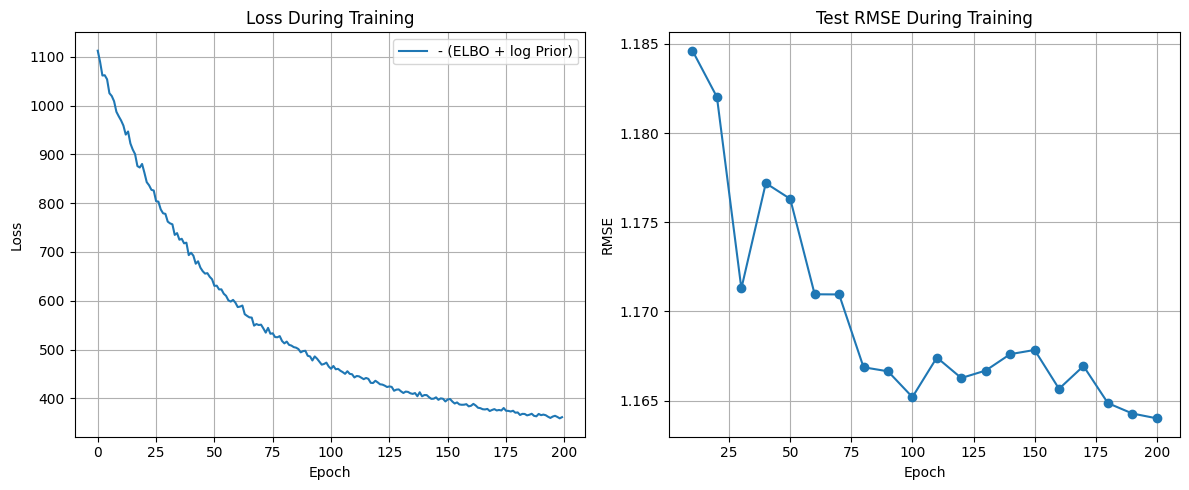

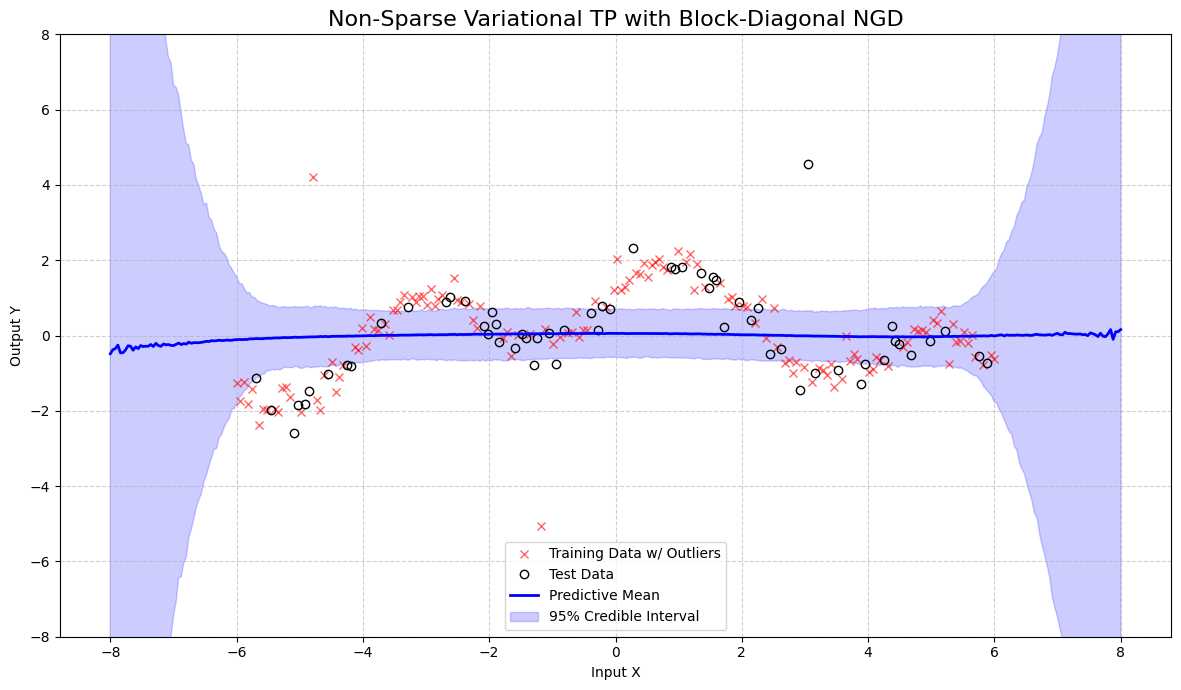

In [31]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

# Assuming these are in a 'student' directory or accessible
from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class XuTPR(nn.Module):
    """
    Non-Sparse Variational Student-t Process Regression with Natural Gradient Descent.
    
    This version uses a **numerically stable block-diagonal approximation** for the
    Fisher Information Matrix (FIM), which decouples the natural gradient updates
    for the mean (m), degrees of freedom (dof_q), and scale (S_diag) of the
    variational posterior.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape
        dtype = self.X_train.dtype

        # Priors for Hyperparameters
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0)

        # Initialize Hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # Variational Parameters for q(f) (DIAGONAL COVARIANCE)
        self.m = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.log_S_diag = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Kernel function
        self.kernel = rbf_kernel if kernel in (None, "rbf") else matern52_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_train.dtype
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode, init_val = settings.get("optim", "MLE"), settings.get("init", None)
            self.hyper_optim_mode[name] = mode
            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.1)
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
            initialized_params[name] = final_value
        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=2.0 + EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=2.0 + EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }
    
    def _get_variational_params(self):
         return {
            "m": self.m,
            "S_diag": torch.exp(self.log_S_diag).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=2.0 + EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior
    
    def calculate_elbo(self, num_samples=1):
        hyper_params = self._get_hyperparams()
        var_params = self._get_variational_params()
        scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
        f_samples = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
        lik_dist = torch.distributions.StudentT(df=hyper_params['dof_lik'], loc=f_samples, scale=hyper_params['noisescale'])
        expected_log_lik = lik_dist.log_prob(self.y_train).sum(0).mean()
        K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
        K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
        K_XX_chol = K_XX_op.cholesky()
        kl_div = kl_mvt_empirical(
            mu_q=var_params['m'], scale_tril_q=scale_tril_q, dof_q=var_params['dof_q'],
            mu_p=torch.zeros_like(var_params['m']), scale_tril_p=K_XX_chol, dof_p=hyper_params['dof_func'],
            num_samples=num_samples)
        return expected_log_lik - kl_div

    def _create_fim_inverse_block_diag(self):
        """
        Computes the inverse of the Fisher Information Matrix (FIM) for q(f)
        using a **block-diagonal approximation**. This is numerically stable and
        efficient, assuming no geometric coupling between {m}, {v}, and {S}.
        """
        var_params = self._get_variational_params()
        v, S_diag = var_params['dof_q'], var_params['S_diag']
        N = self.N
        log_beta = lambda a, b: torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)
        B1_log = log_beta(torch.tensor((N + 3) / 2, device=self.device), (v - 1) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
        B2_log = log_beta(torch.tensor((N + 5) / 2, device=self.device), (v - 2) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
        B1, B2 = torch.exp(B1_log), torch.exp(B2_log)
        # Block 1: Inverse FIM for m
        Fm_diag = ((v + N)**2 / (N * (v - 2))) * B1 / S_diag.squeeze()
        inv_Fm_diag = 1.0 / Fm_diag
        # Block 2: Inverse FIM for v
        alpha_v = 0.5 * (torch.digamma((v + N) / 2) - torch.digamma(v / 2)) - 1 / (v - 2)
        F_v = alpha_v**2 + ((v + N) / (v - 2)) * B1 * alpha_v + ((v + N)**2 / (4 * (v - 2)**2)) * B2
        inv_F_v = 1.0 / F_v
        # Block 3: Inverse FIM for S (using diagonal approximation of F_S)
        diag_term_S = (1/(N+2)) * (2*(v+N)/(v-2)*B1 + 5*(v+N)**2/((v-2)**2 * (N+4))*B2)
        FS_diag = diag_term_S / S_diag.squeeze()
        inv_FS_diag = 1.0 / FS_diag
        return inv_Fm_diag, inv_F_v, inv_FS_diag

    def e_step(self, lr):
        """
        Performs a natural gradient update on the variational parameters
        using the stable block-diagonal FIM approximation.
        """
        inv_Fm_diag, inv_F_v, inv_FS_diag = self._create_fim_inverse_block_diag()
        grad_m = self.m.grad.squeeze()
        grad_v = self.log_dof_q.grad
        grad_S = self.log_S_diag.grad
        # Calculate natural gradients for each block independently
        nat_grad_m = inv_Fm_diag * grad_m
        nat_grad_v = inv_F_v * grad_v
        nat_grad_S = inv_FS_diag * grad_S.squeeze()
        # Apply manual updates to the parameters
        with torch.no_grad():
            self.m.data -= lr * nat_grad_m.unsqueeze(1)
            self.log_dof_q.data -= lr * nat_grad_v
            self.log_S_diag.data -= lr * nat_grad_S.unsqueeze(1)

    def m_step(self, optimizer):
        """Performs a standard Adam update on the model hyperparameters."""
        optimizer.step()

    def fit(self, epochs=200, lr_hyper=0.01, lr_variational=0.1, num_mc_samples=8, X_test=None, y_test=None, eval_interval=10):
        hyper_params_to_opt = []
        for name, p in self.named_parameters():
            if name in ['log_lengthscale', 'log_outputscale', 'log_dof_func', 'log_dof_lik', 'log_noisescale']:
                if self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                    hyper_params_to_opt.append(p)
        hyper_optimizer = optim.Adam(hyper_params_to_opt, lr=lr_hyper) if hyper_params_to_opt else None
        
        history = {'elbo': [], 'loss': [], 'eval_epochs': [], 'eval_metrics': [], 'fit_times': []}
        logging.info(f"Starting training for {epochs} epochs with Natural Gradients...")

        for epoch in range(epochs):
            fit_start_time = time.time()
            self.train()
            # E-M Step
            if hyper_optimizer: hyper_optimizer.zero_grad()
            self.m.grad, self.log_S_diag.grad, self.log_dof_q.grad = None, None, None
            
            elbo = self.calculate_elbo(num_samples=num_mc_samples)
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(elbo + log_prior)
            loss.backward()
            
            if hyper_optimizer: self.m_step(hyper_optimizer) # M-Step
            self.e_step(lr=lr_variational) # E-Step
            
            fit_end_time = time.time()
            history.update(elbo=history['elbo']+[elbo.item()], loss=history['loss']+[loss.item()], fit_times=history['fit_times']+[fit_end_time - fit_start_time])

            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")
        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_train.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        with torch.no_grad():
            hyper_params = self._get_hyperparams()
            var_params = self._get_variational_params()
            scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
            f_samples_posterior = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
            K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, hyper_params['lengthscale'], hyper_params['outputscale']).diag()
            K_inv_f_samples = K_XX_op.solve(f_samples_posterior)
            predictive_loc_per_sample = K_star_X @ K_inv_f_samples
            beta_per_sample = (f_samples_posterior * K_inv_f_samples).sum(0)
            dof_pred = hyper_params['dof_func'] + self.N
            K_star_X_K_inv = K_XX_op.solve(K_star_X.T).T
            term2 = (K_star_X_K_inv * K_star_X).sum(1)
            scale_factor = (hyper_params['dof_func'] + beta_per_sample) / dof_pred
            scale_base = k_star_star_diag - term2
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            pred_dist = torch.distributions.StudentT(
                df=dof_pred, loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON)))
            predictive_samples = pred_dist.sample()
        self.train()
        return predictive_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test):
        predictive_samples = self.predict(X_test, num_samples=1000)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}


# --- Main execution block for testing ---
if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    import matplotlib.pyplot as plt
    from scipy.stats import t as scipy_t

    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # 1. Generate synthetic data
    torch.manual_seed(42); np.random.seed(42)
    X_data = torch.linspace(-6, 6, 200).unsqueeze(1)
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    noise = torch.from_numpy(scipy_t.rvs(df=3, size=200)).unsqueeze(1) * 0.25
    y_data = y_true + noise
    y_data[[20, 80, 150]] += torch.tensor([[6.0], [-5.0], [5.5]])
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # 2. Initialize and train the model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'}, 
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'}, 
        'dof_func': {'optim': 'MAP'}, 
        'dof_lik': {'optim': 'MAP'},
    }
    model = XuTPR(X_train, y_train, hyper_settings=hyper_settings, device=device)
    
    history = model.fit(
        epochs=200, lr_hyper=0.01, lr_variational=0.1, num_mc_samples=1000,
        X_test=X_test, y_test=y_test, eval_interval=10
    )
    
    # 3. Plot optimization history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.plot(history['loss'], label='- (ELBO + log Prior)')
    plt.title("Loss During Training"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(history['eval_epochs'], [m['rmse'] for m in history['eval_metrics']], 'o-')
    plt.title("Test RMSE During Training"); plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.grid(True); plt.tight_layout(); plt.show()
    
    # 4. Make final predictions and plot the result
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=10000)
    mu_pred = np.mean(predictive_samples, axis=1)
    lower, upper = np.quantile(predictive_samples, [0.025, 0.975], axis=1)
    plt.figure(figsize=(12, 7))
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data w/ Outliers', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(X_plot.squeeze().cpu(), lower, upper, color='blue', alpha=0.2, label='95% Credible Interval')
    plt.title('Non-Sparse Variational TP with Block-Diagonal NGD', fontsize=16)
    plt.xlabel('Input X'); plt.ylabel('Output Y'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.ylim(-8, 8); plt.show()

In [1]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

# Assuming these are in a local directory or installed package
from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class XuTPR(nn.Module):
    """
    Non-Sparse Variational Student-t Process Regression with Natural Gradient Descent.
    
    This version uses a **numerically stable block-diagonal approximation** for the
    Fisher Information Matrix (FIM) to enable Natural Gradient Descent (NGD)
    for variational parameters, while using Adam for hyperparameters.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        # --- FIX: Corrected the typo from --1 to -1 ---
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape
        dtype = self.X_train.dtype

        # Priors for Hyperparameters
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0)

        # Initialize Hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # Variational Parameters for q(f) (DIAGONAL COVARIANCE)
        self.m = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.log_S_diag = nn.Parameter(torch.zeros(self.N, 1, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Kernel function
        self.kernel = rbf_kernel if kernel in (None, "rbf") else matern52_kernel
        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_train.dtype
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode, init_val = settings.get("optim", "MLE"), settings.get("init", None)
            self.hyper_optim_mode[name] = mode
            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.1)
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
            initialized_params[name] = final_value
        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=2.0 + EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=2.0 + EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }
    
    def _get_variational_params(self):
         return {
            "m": self.m,
            "S_diag": torch.exp(self.log_S_diag).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=2.0 + EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior
    
    def calculate_elbo(self, num_samples=1):
        hyper_params = self._get_hyperparams()
        var_params = self._get_variational_params()
        scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
        f_samples = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
        lik_dist = torch.distributions.StudentT(df=hyper_params['dof_lik'], loc=f_samples, scale=hyper_params['noisescale'])
        expected_log_lik = lik_dist.log_prob(self.y_train).sum(0).mean()
        K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
        K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
        K_XX_chol = K_XX_op.cholesky()
        kl_div = kl_mvt_empirical(
            mu_q=var_params['m'], scale_tril_q=scale_tril_q, dof_q=var_params['dof_q'],
            mu_p=torch.zeros_like(var_params['m']), scale_tril_p=K_XX_chol, dof_p=hyper_params['dof_func'],
            num_samples=num_samples)
        return expected_log_lik - kl_div

    def _create_fim_inverse_block_diag(self):
        var_params = self._get_variational_params()
        v, S_diag = var_params['dof_q'], var_params['S_diag']
        N = self.N
        log_beta = lambda a, b: torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)
        B1_log = log_beta(torch.tensor((N + 3) / 2, device=self.device), (v - 1) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
        B2_log = log_beta(torch.tensor((N + 5) / 2, device=self.device), (v - 2) / 2) - log_beta(torch.tensor(N / 2, device=self.device), v / 2)
        B1, B2 = torch.exp(B1_log), torch.exp(B2_log)
        Fm_diag = ((v + N)**2 / (N * (v - 2))) * B1 / S_diag.squeeze()
        inv_Fm_diag = 1.0 / Fm_diag
        alpha_v = 0.5 * (torch.digamma((v + N) / 2) - torch.digamma(v / 2)) - 1 / (v - 2)
        F_v = alpha_v**2 + ((v + N) / (v - 2)) * B1 * alpha_v + ((v + N)**2 / (4 * (v - 2)**2)) * B2
        inv_F_v = 1.0 / F_v
        diag_term_S = (1/(N+2)) * (2*(v+N)/(v-2)*B1 + 5*(v+N)**2/((v-2)**2 * (N+4))*B2)
        FS_diag = diag_term_S / S_diag.squeeze()
        inv_FS_diag = 1.0 / FS_diag
        return inv_Fm_diag, inv_F_v, inv_FS_diag

    def e_step(self, lr):
        inv_Fm_diag, inv_F_v, inv_FS_diag = self._create_fim_inverse_block_diag()
        grad_m, grad_v, grad_S = self.m.grad, self.log_dof_q.grad, self.log_S_diag.grad
        nat_grad_m = inv_Fm_diag * grad_m.squeeze()
        nat_grad_v = inv_F_v * grad_v
        nat_grad_S = inv_FS_diag * grad_S.squeeze()
        with torch.no_grad():
            self.m.data -= lr * nat_grad_m.unsqueeze(1)
            self.log_dof_q.data -= lr * nat_grad_v
            self.log_S_diag.data -= lr * nat_grad_S.unsqueeze(1)

    def m_step(self, optimizer):
        optimizer.step()

    def fit(self, epochs=200, lr_hyper=0.01, lr_variational=0.1, num_mc_samples=8, X_test=None, y_test=None, eval_interval=10):
        hyper_params_to_opt = []
        for name, p in self.named_parameters():
            if name in ['log_lengthscale', 'log_outputscale', 'log_dof_func', 'log_dof_lik', 'log_noisescale']:
                if self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                    hyper_params_to_opt.append(p)
        hyper_optimizer = optim.Adam(hyper_params_to_opt, lr=lr_hyper) if hyper_params_to_opt else None
        
        history = {'elbo': [], 'loss': [], 'eval_epochs': [], 'eval_metrics': [], 'fit_times': []}
        logging.info(f"Starting training for {epochs} epochs with NGD...")

        for epoch in range(epochs):
            fit_start_time = time.time()
            self.train()
            # E-M Step
            if hyper_optimizer: hyper_optimizer.zero_grad()
            self.m.grad, self.log_S_diag.grad, self.log_dof_q.grad = None, None, None
            
            elbo = self.calculate_elbo(num_samples=num_mc_samples)
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(elbo + log_prior)
            loss.backward()
            
            if hyper_optimizer: self.m_step(hyper_optimizer) # M-Step
            self.e_step(lr=lr_variational) # E-Step
            
            fit_end_time = time.time()
            history.update(elbo=history['elbo']+[elbo.item()], loss=history['loss']+[loss.item()], fit_times=history['fit_times']+[fit_end_time - fit_start_time])

            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")
        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_train.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        with torch.no_grad():
            hyper_params = self._get_hyperparams()
            var_params = self._get_variational_params()
            scale_tril_q = torch.diag(torch.sqrt(var_params['S_diag'].squeeze()))
            f_samples_posterior = sample_mvt(var_params['m'], scale_tril_q, var_params['dof_q'], num_samples)
            
            K_XX_base = self.kernel(self.X_train, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_train, hyper_params['lengthscale'], hyper_params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, hyper_params['lengthscale'], hyper_params['outputscale']).diag()
            K_inv_f_samples = K_XX_op.solve(f_samples_posterior)
            predictive_loc_per_sample = K_star_X @ K_inv_f_samples
            beta_per_sample = (f_samples_posterior * K_inv_f_samples).sum(0)
            dof_pred = hyper_params['dof_func'] + self.N
            K_star_X_K_inv = K_XX_op.solve(K_star_X.T).T
            term2 = (K_star_X_K_inv * K_star_X).sum(1)
            scale_factor = (hyper_params['dof_func'] + beta_per_sample) / dof_pred
            scale_base = k_star_star_diag - term2
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            pred_dist = torch.distributions.StudentT(
                df=dof_pred, loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON)))
            predictive_samples = pred_dist.sample()
        self.train()
        return predictive_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test):
        predictive_samples = self.predict(X_test, num_samples=1000)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}

2025-09-14 17:53:41,388 - INFO - Starting training for 2000 epochs with NGD...
2025-09-14 17:53:41,587 - INFO - Epoch   10/2000 | Fit Time: 0.020s | Loss: 978.061 | ELBO: -974.291
2025-09-14 17:53:41,593 - INFO - Epoch   10 | Test RMSE: 1.1846
2025-09-14 17:53:41,793 - INFO - Epoch   20/2000 | Fit Time: 0.019s | Loss: 880.410 | ELBO: -876.639
2025-09-14 17:53:41,800 - INFO - Epoch   20 | Test RMSE: 1.1820
2025-09-14 17:53:42,005 - INFO - Epoch   30/2000 | Fit Time: 0.022s | Loss: 778.113 | ELBO: -774.287
2025-09-14 17:53:42,012 - INFO - Epoch   30 | Test RMSE: 1.1713
2025-09-14 17:53:42,212 - INFO - Epoch   40/2000 | Fit Time: 0.019s | Loss: 693.564 | ELBO: -689.633
2025-09-14 17:53:42,219 - INFO - Epoch   40 | Test RMSE: 1.1772
2025-09-14 17:53:42,424 - INFO - Epoch   50/2000 | Fit Time: 0.020s | Loss: 644.103 | ELBO: -640.006
2025-09-14 17:53:42,432 - INFO - Epoch   50 | Test RMSE: 1.1763
2025-09-14 17:53:42,634 - INFO - Epoch   60/2000 | Fit Time: 0.020s | Loss: 596.186 | ELBO: -591

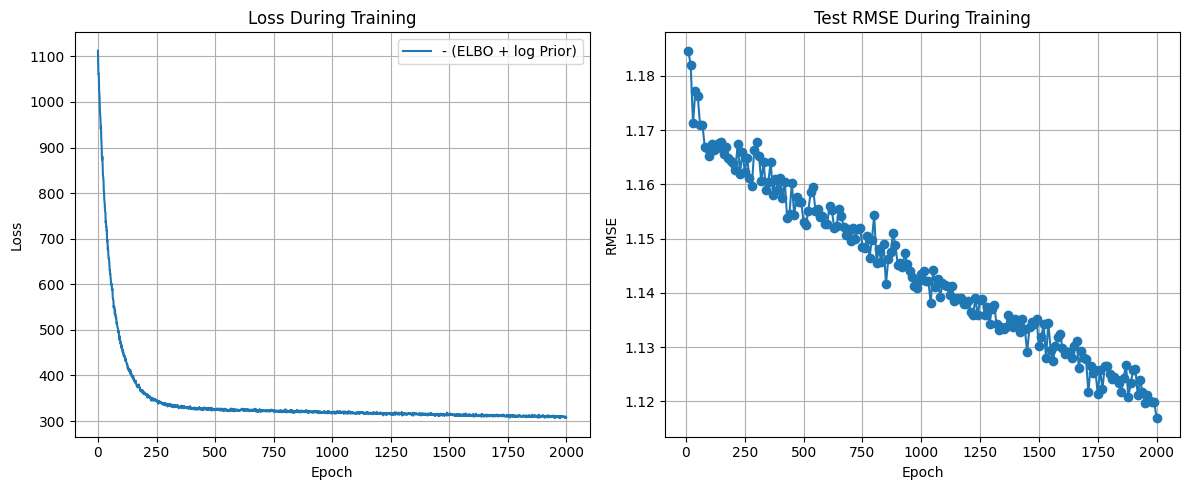

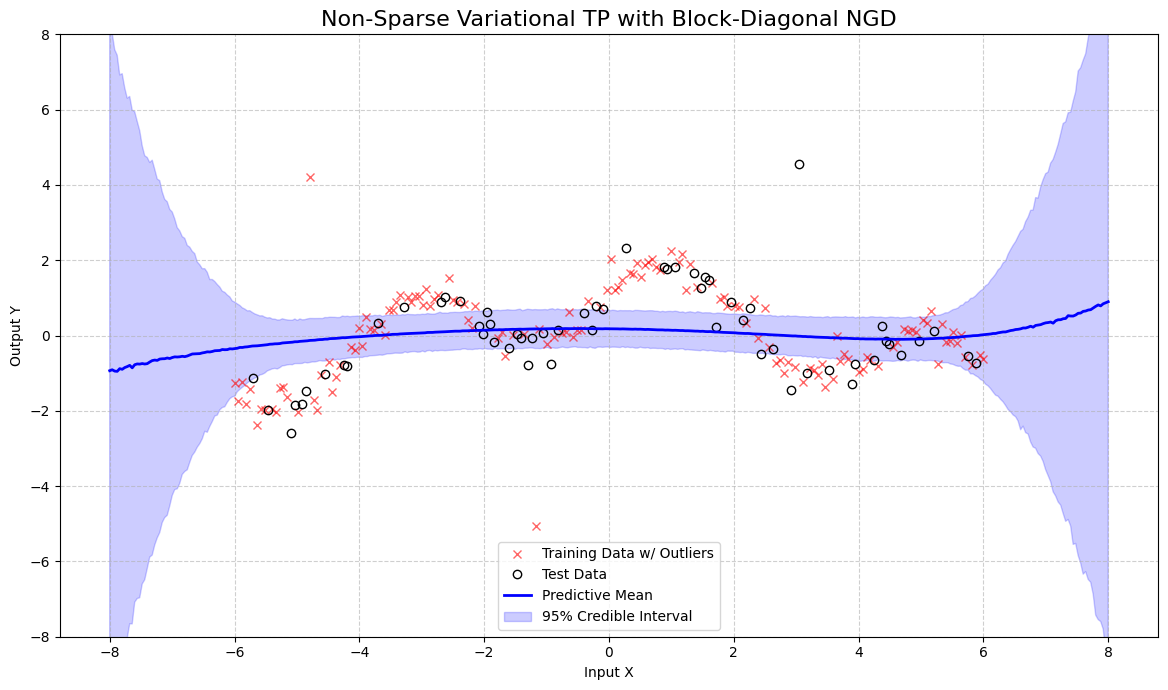

In [3]:

# --- Main execution block for testing ---
if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    import matplotlib.pyplot as plt
    from scipy.stats import t as scipy_t

    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    
    # 1. Generate synthetic data
    torch.manual_seed(42); np.random.seed(42)
    X_data = torch.linspace(-6, 6, 200).unsqueeze(1)
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    noise = torch.from_numpy(scipy_t.rvs(df=3, size=200)).unsqueeze(1) * 0.25
    y_data = y_true + noise
    y_data[[20, 80, 150]] += torch.tensor([[6.0], [-5.0], [5.5]])
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # 2. Initialize and train the model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'}, 
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'}, 
        'dof_func': {'optim': 'MAP'}, 
        'dof_lik': {'optim': 'MAP'},
    }
    model = XuTPR(X_train, y_train, hyper_settings=hyper_settings, device=device)
    
    history = model.fit(
        epochs=2000, lr_hyper=0.01, lr_variational=0.1, num_mc_samples=1000,
        X_test=X_test, y_test=y_test, eval_interval=10
    )
    
    # 3. Plot optimization history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.plot(history['loss'], label='- (ELBO + log Prior)')
    plt.title("Loss During Training"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(history['eval_epochs'], [m['rmse'] for m in history['eval_metrics']], 'o-')
    plt.title("Test RMSE During Training"); plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.grid(True); plt.tight_layout(); plt.show()
    
    # 4. Make final predictions and plot the result
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=10000)
    mu_pred = np.mean(predictive_samples, axis=1)
    lower, upper = np.quantile(predictive_samples, [0.025, 0.975], axis=1)
    plt.figure(figsize=(12, 7))
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data w/ Outliers', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(X_plot.squeeze().cpu(), lower, upper, color='blue', alpha=0.2, label='95% Credible Interval')
    plt.title('Non-Sparse Variational TP with Block-Diagonal NGD', fontsize=16)
    plt.xlabel('Input X'); plt.ylabel('Output Y'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.ylim(-8, 8); plt.show()